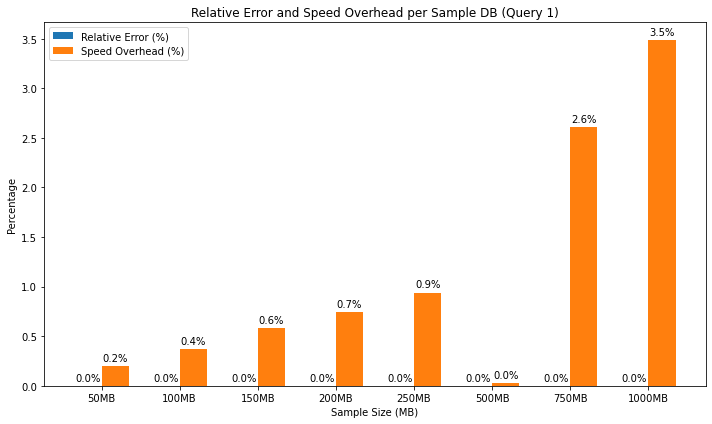

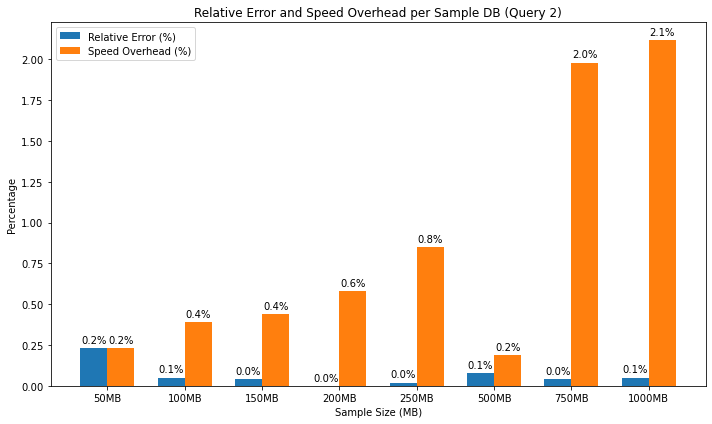

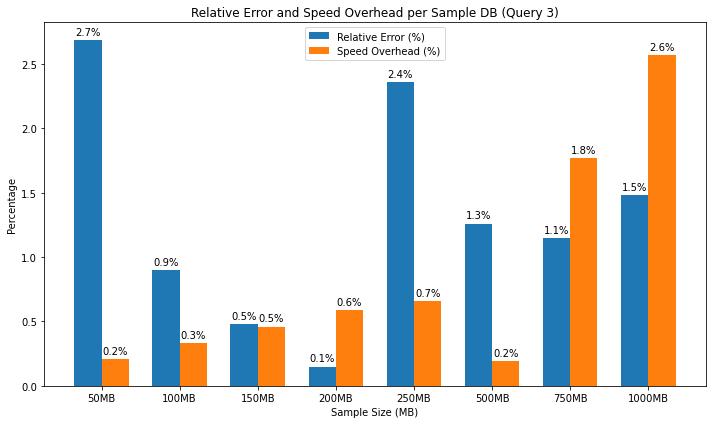

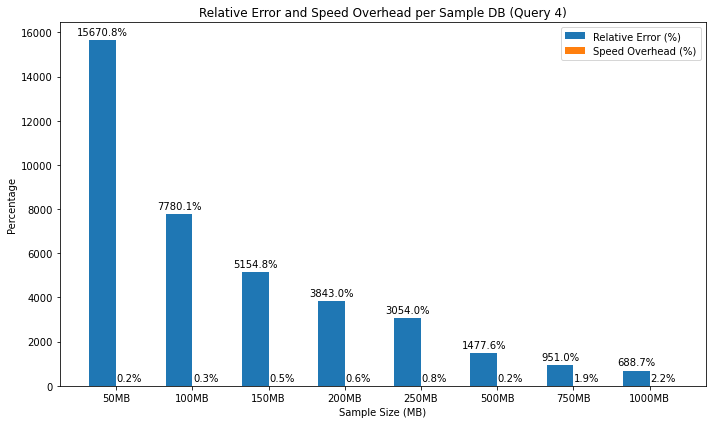

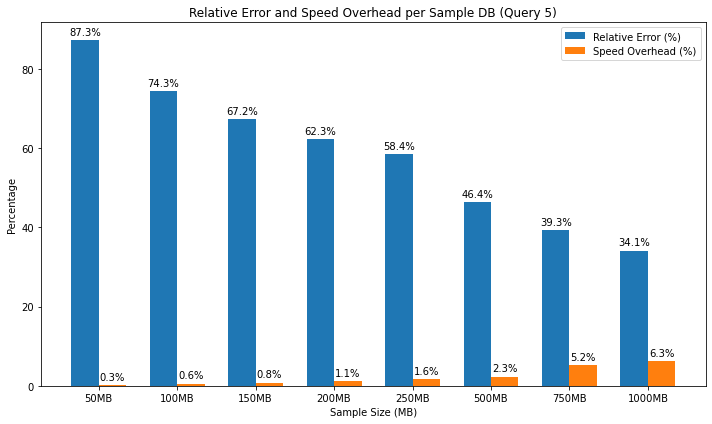

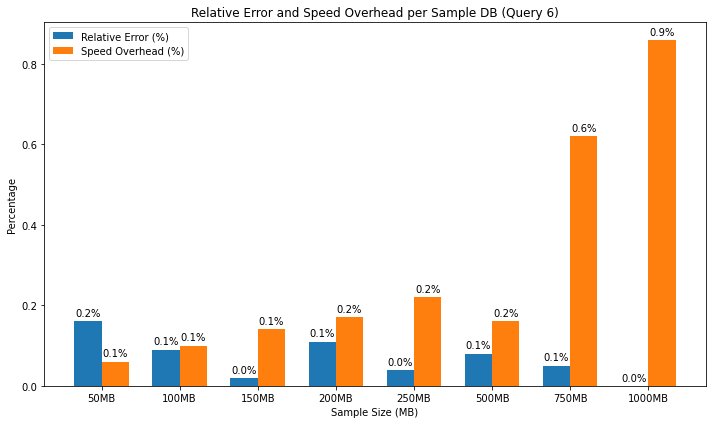

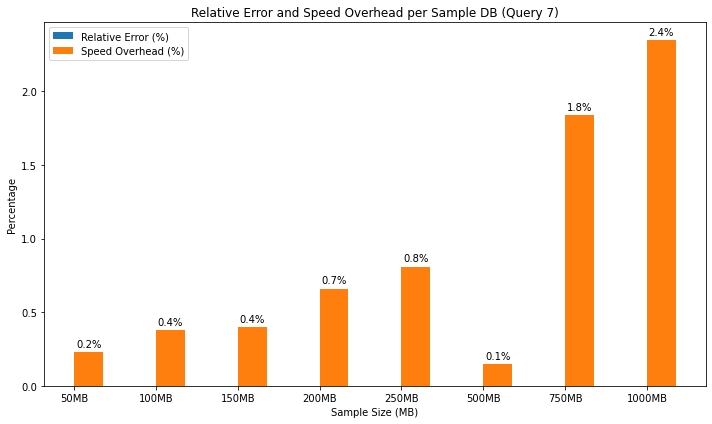

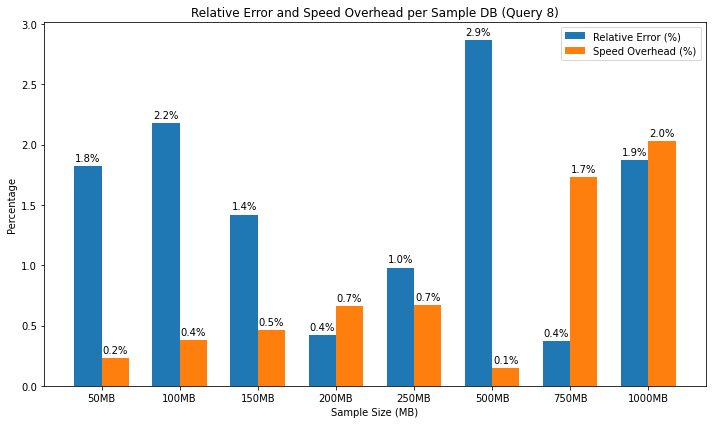

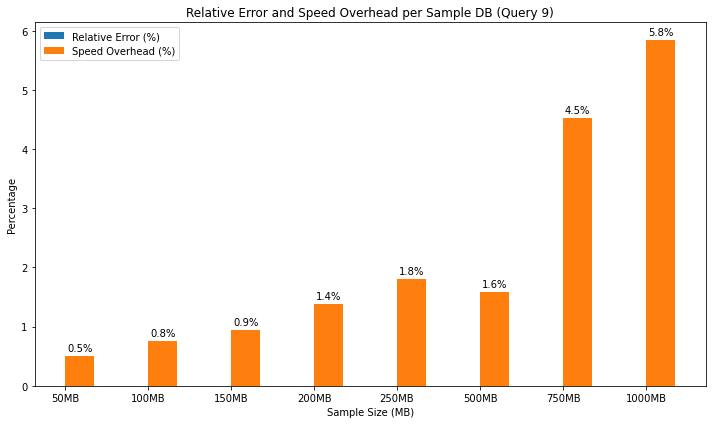

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Load CSV
df = pd.read_csv('errors_overhead.csv')

# Dynamically identify relevant columns
query_col = next(col for col in df.columns if 'query' in col.lower())
sample_col = next(col for col in df.columns if 'db' in col.lower() or 'database' in col.lower())
error_col = next(col for col in df.columns if 'error' in col.lower())
overhead_col = next(col for col in df.columns if 'overhead' in col.lower())

# Extract sample size (in MB) from sample database name
df['Sample_MB'] = df[sample_col].astype(str).str.extract(r'(\d+)').astype(float)

# Convert metrics to numeric
df[error_col] = pd.to_numeric(df[error_col], errors='coerce')
df[overhead_col] = pd.to_numeric(df[overhead_col], errors='coerce')

# Create output folder
output_folder = 'query'
os.makedirs(output_folder, exist_ok=True)

# Generate bar charts per query, save and display
for idx, query in enumerate(df[query_col].unique(), start=1):
    sub = df[df[query_col] == query].sort_values('Sample_MB')

    x = np.arange(len(sub))  # label locations
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, sub[error_col], width, label='Relative Error (%)')
    bars2 = ax.bar(x + width/2, sub[overhead_col], width, label='Speed Overhead (%)')

    ax.set_xlabel('Sample Size (MB)')
    ax.set_ylabel('Percentage')
    ax.set_title(f'Relative Error and Speed Overhead per Sample DB (Query {idx})')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(mb)}MB" for mb in sub['Sample_MB']])
    ax.legend()

    # Annotate bars
    for bar in bars1 + bars2:
        height = bar.get_height()
        if not pd.isna(height):
            ax.annotate(f'{height:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    plt.tight_layout()

    # Save and show plot
    filename = f"query_{idx}.png"
    filepath = os.path.join(output_folder, filename)
    plt.savefig(filepath)
    plt.show()
